In [78]:
from glob import glob
import pandas as pd

In [79]:
# glob('../dataset_48k/audio/01/*.wav')

In [80]:
import librosa.display
import matplotlib.pylab as plt
import IPython.display as ipd


In [81]:
# data = glob('../dataset_48k/audio/01/*.wav')
data = "0_33_0.wav"

In [82]:
y, sr = librosa.load(data, sr = None)

In [83]:
print(sr)

8000


In [84]:
import librosa
original_data, sr = librosa.load(data, sr=None)
print(sr)
resampled_data = librosa.resample(original_data, orig_sr=sr, target_sr=8000)
print(resampled_data.shape)
ipd.Audio(original_data, rate=sr)


8000
(5594,)


In [85]:
frequency = librosa.get_samplerate(data)
print(f"The frequency of the WAV file is {frequency} Hz.")

The frequency of the WAV file is 8000 Hz.


In [86]:
ipd.Audio(resampled_data, rate=8000)

<Axes: title={'center': 'Waveform'}>

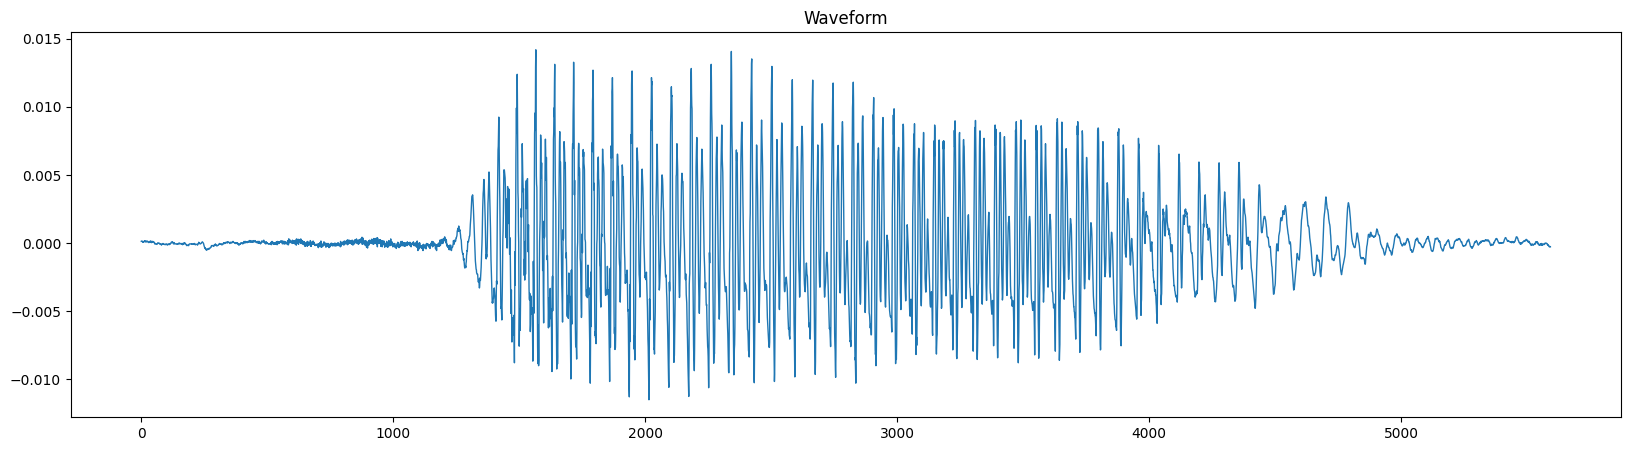

In [87]:
pd.Series(original_data).plot(figsize=(20, 5), lw=1, title='Waveform')


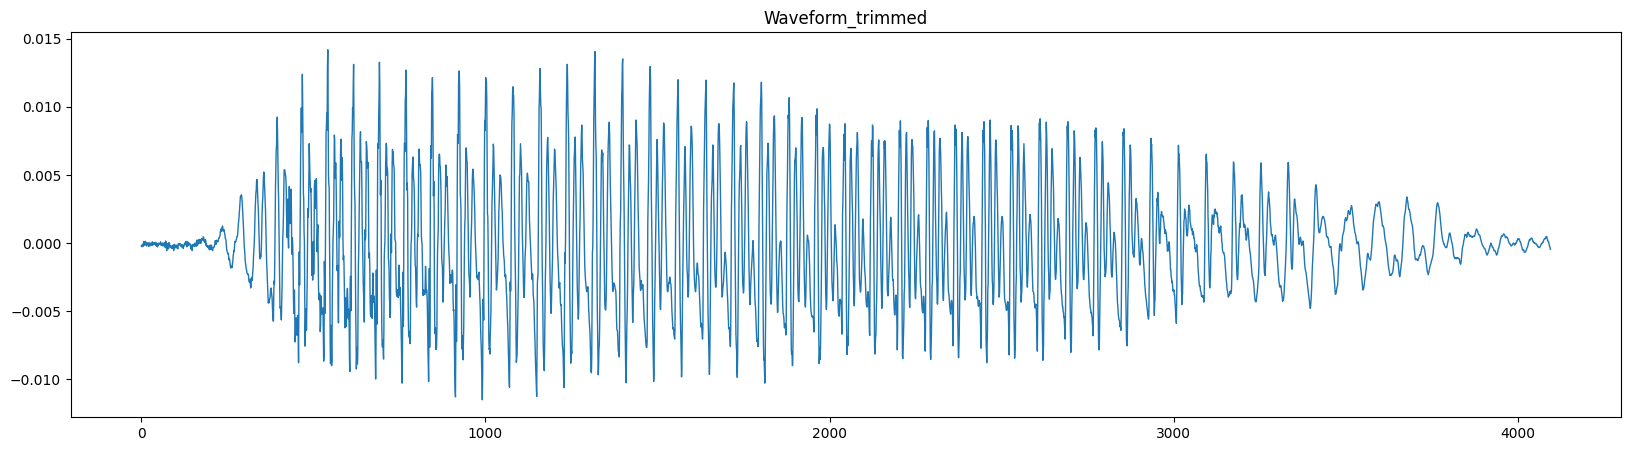

In [88]:
y_trimmed,_ = librosa.effects.trim(resampled_data, top_db=10)
pd.Series(y_trimmed).plot(figsize=(20, 5), lw=1, title='Waveform_trimmed')
plt.show()


In [89]:
import os
import subprocess
import shutil
DATASET_AUDIO_PATH = "D:\\speaker_iden\\dataset_48k\\audio"
# Lấy danh sách tất cả các thư mục con trong DATASET_AUDIO_PATH
dirs = os.listdir(DATASET_AUDIO_PATH)

for dir in dirs:
    # Lấy danh sách tất cả các tệp âm thanh WAV trong mỗi thư mục con
    files = os.listdir(os.path.join(DATASET_AUDIO_PATH, dir))

    for file in files:
        file_path = os.path.join(DATASET_AUDIO_PATH, dir, file)

        # Sử dụng subprocess để chạy lệnh ffprobe và lấy thông tin về tỷ lệ mẫu
        ffprobe_command = ['ffprobe', '-hide_banner', '-loglevel', 'panic', '-show_streams', file_path]
        output = subprocess.check_output(ffprobe_command).decode('utf-8')
        sample_rate_line = [line for line in output.split('\n') if 'sample_rate' in line][0]
        sample_rate = int(sample_rate_line.split('=')[1])

        if sample_rate != 8000:
            # Sử dụng subprocess để chạy lệnh ffmpeg để chuyển đổi tỷ lệ mẫu
            temp_file_path = os.path.join(DATASET_AUDIO_PATH, dir, 'temp.wav')
            ffmpeg_command = ['ffmpeg', '-hide_banner', '-loglevel', 'panic', '-y', '-i', file_path, '-ar', '16000', temp_file_path]
            subprocess.check_call(ffmpeg_command)

            # Di chuyển tệp âm thanh mới có tỷ lệ mẫu 16000 vào vị trí tệp gốc
            shutil.move(temp_file_path, file_path)

FileNotFoundError: [WinError 2] The system cannot find the file specified

In [8]:
import os
import shutil
import numpy as np

import tensorflow as tf
import keras

from pathlib import Path
from IPython.display import display, Audio

In [9]:
import tensorflow as tf

# fft test
def audio_to_fft(audio):
    # Since tf.signal.fft applies FFT on the innermost dimension,
    # we need to squeeze the dimensions and then expand them again
    # after FFT
    audio = tf.squeeze(audio, axis=-1)
    fft = tf.signal.fft(
        tf.cast(tf.complex(real=audio, imag=tf.zeros_like(audio)), tf.complex64)
    )
    fft = tf.expand_dims(fft, axis=-1)

    # Return the absolute value of the first half of the FFT
    # which represents the positive frequencies
    return tf.math.abs(fft[:, : (audio.shape[1] // 2), :])

In [48]:
path = "0_02_0.wav"
SAMPLING_RATE = 8000
audio = tf.io.read_file(path)
audio, _ = tf.audio.decode_wav(audio, 1, SAMPLING_RATE)
print(audio)
audio = tf.squeeze(audio, axis=-1)
print(audio.shape)

fft = tf.signal.fft(
  tf.cast(tf.complex(real=audio, imag=tf.zeros_like(audio)), tf.complex64)
)
fft = tf.expand_dims(fft, axis=-1)

print(fft)

tf.Tensor(
[[3.0517578e-05]
 [0.0000000e+00]
 [6.1035156e-05]
 ...
 [0.0000000e+00]
 [0.0000000e+00]
 [0.0000000e+00]], shape=(8000, 1), dtype=float32)
(8000,)
tf.Tensor(
[[-0.01550293+0.j        ]
 [ 0.09511821+0.00647142j]
 [ 0.09588694+0.00084597j]
 ...
 [-0.01079108-0.06355891j]
 [ 0.09588696-0.00084594j]
 [ 0.09511818-0.00647143j]], shape=(8000, 1), dtype=complex64)


In [ ]:
def wav2mfcc(file_path, n_mfcc=20, max_len=11):
    wave, sr = librosa.load(file_path, mono=True, sr=None)
    wave = np.asfortranarray(wave[::3])
    mfcc = librosa.feature.mfcc(wave, sr=16000, n_mfcc=n_mfcc)
    if (max_len > mfcc.shape[1]):
        pad_width = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]
    return mfcc

In [45]:
path = "0_33_0.wav"
